In [1]:
import torch
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer, EsmForMaskedLM
from tokenizers import Tokenizer
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os
import csv

from scipy.stats import spearmanr

/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from plm_compare_progen2 import *
from protein_data import *

Could try NDCG or AUC.

In [ ]:
# def dcg(relevances, k=None):
#     if k is None:
#         k = len(relevances)
#     relevances = np.array(relevances)[:k]
#     ranks = np.arange(1, len(relevances) + 1)
#     return np.sum((2**relevances - 1) / np.log2(ranks + 1))

# def ndcg(relevances, k=None):
#     if k is None:
#         k = len(relevances)
#     relevances = np.array(relevances)
    
#     dcg_k = dcg(relevances, k)
#     ideal_relevances = np.sort(relevances)[::-1]
#     idcg_k = dcg(ideal_relevances, k)
    
#     if idcg_k == 0:
#         return 0.0
#     return dcg_k / idcg_k


In [3]:
with open('/Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/pg2_ProGym_matrices.pickle',
           'rb') as f:
    pg_dict = pickle.load(f)

In [4]:
keys = list(pg_dict.keys())

In [5]:
i = 43

DMS = pg_dict[keys[i]]['DMS']
LLR = pg_dict[keys[i]]['llr_matrix']
seq = pg_dict[keys[i]]['sequence']

In [6]:
len(DMS)

352

In [22]:
def masked_softmax_rows(X):
    X = np.array(X, dtype=float)

    mask = ~np.isnan(X)

    X_filled = np.where(mask, X, -np.inf)

    # stability trick: subtract row max over valid entries
    row_max = np.nanmax(X_filled, axis=1, keepdims=True)
    e = np.exp(X_filled - row_max)

    # zero out invalid positions
    e = e * mask

    row_sum = e.sum(axis=1, keepdims=True)
    return e / row_sum

def safe_log(x):
    x = np.asarray(x)
    out = np.empty_like(x)
    mask = ~np.isnan(x)
    out[mask] = np.log(x[mask])
    out[~mask] = np.nan
    return out

In [15]:
print(seq)
print(DMS[20])

DMS_sm = masked_softmax_rows(DMS)

print(DMS_sm[20])


MDYQVSSPIYDINYYTSEPCQKINVKQIAARLLPPLYSLVFIFGFVGNMLVILILINCKRLKSMTDIYLLNLAISDLFFLLTVPFWAHYAAAQWDFGNTMCQLLTGLYFIGFFSGIFFIILLTIDRYLAVVHAVFALKARTVTFGVVTSVITWVVAVFASLPGIIFTRSQKEGLHYTCSSHFPYSQYQFWKNFQTLKIVILGLVLPLLVMVICYSGILKTLLRCRNEKKRHRAVRLIFTIMIVYFLFWAPYNIVLLLNTFQEFFGLNNCSSSNRLDQAMQVTETLGMTHCCINPIIYAFVGEKFRNYLLVFFQKHIAKRFCKCCSIFQQEAPERASSVYTRSTGEQEISVGL
[ 1.05   0.7    0.29   0.775  0.51   0.885  0.13   0.48   3.38   0.64
  0.275 -0.325  0.485    nan  0.575  0.575  0.59   1.05   0.745  0.235]
[0.04628574 0.03261701 0.02164629 0.03515736 0.02697294 0.03924539
 0.01844575 0.02617577 0.47572216 0.03071754 0.02132402 0.01170287
 0.02630697 0.         0.02878441 0.02878441 0.02921943 0.04628574
 0.0341183  0.02048789]


/var/folders/30/5r4_75_n4bz34nyphw8tfv3m0000gn/T/ipykernel_4895/2439675481.py:10: RuntimeWarning: invalid value encountered in subtract
  e = np.exp(X_filled - row_max)


In [8]:
count_nan = sum(np.isnan(x) for x in DMS)
print(count_nan)
print(count_nan.sum())

[30 41 36 37 60 44 36 60 44 71 36 44 40 44 44 50 50 56 34 47]
904


In [9]:
count_nan = np.isnan(DMS).sum()
print(count_nan, 20*len(seq))

904 7040


In [17]:
def spearman_ignore_nan(a, b):
    mask = ~np.isnan(a) & ~np.isnan(b)
    return spearmanr(a[mask], b[mask])

In [ ]:
# sp_list = []
# n = len(pg_dict[keys[25]]['sequence'])

# for i in range(n):
#     x = pg_dict[keys[25]]['DMS'][i]
#     y = pg_dict[keys[25]]['llr_matrix'][i]

#     corr, p_value = spearman_ignore_nan(x, y)

#     sp_list.append(corr)

In [47]:
# count_nan = sum(np.isnan(x) for x in sp_list)
# count_nan

In [19]:
i=25

x = pg_dict[keys[i]]['DMS']
y = pg_dict[keys[i]]['llr_matrix']
print(x.shape,y.shape)

seq = pg_dict[keys[i]]['sequence']
print(seq)
print(len(seq))

sp_val, p_val = spearman_ignore_nan(x, y)
sp_val

(505, 20) (505, 20)
MGETLGDSPIDPESDSFTDTLSANISQEMTMVDTEMPFWPTNFGISSVDLSVMEDHSHSFDIKPFTTVDFSSISTPHYEDIPFTRTDPVVADYKYDLKLQEYQSAIKVEPASPPYYSEKTQLYNKPHEEPSNSLMAIECRVCGDKASGFHYGVHACEGCKGFFRRTIRLKLIYDRCDLNCRIHKKSRNKCQYCRFQKCLAVGMSHNAIRFGRMPQAEKEKLLAEISSDIDQLNPESADLRALAKHLYDSYIKSFPLTKAKARAILTGKTTDKSPFVIYDMNSLMMGEDKIKFKHITPLQEQSKEVAIRIFQGCQFRSVEAVQEITEYAKSIPGFVNLDLNDQVTLLKYGVHEIIYTMLASLMNKDGVLISEGQGFMTREFLKSLRKPFGDFMEPKFEFAVKFNALELDDSDLAIFIAVIILSGDRPGLLNVKPIEDIQDNLLQALELQLKLNHPESSQLFAKLLQKMTDLRQIVTEHVQLLQVIKKTETDMSLHPLLQEIYKDLY
505


np.float64(0.6710628241863761)

In [54]:
sp_list = []

for i in range(20):
    x = pg_dict[keys[25]]['DMS'][:, i]
    y = pg_dict[keys[25]]['llr_matrix'][:, i]

    corr, p_value = spearman_ignore_nan(x, y)

    sp_list.append(corr)

In [65]:
sp_list = [float(round(x,5)) for x in sp_list]
print(list(zip(list(amino_acids),sp_list)))

[('A', 0.6751), ('C', 0.59368), ('D', 0.7342), ('E', 0.74036), ('F', 0.60456), ('G', 0.70431), ('H', 0.69109), ('I', 0.63679), ('K', 0.71081), ('L', 0.62946), ('M', 0.61278), ('N', 0.73768), ('P', 0.68674), ('Q', 0.70547), ('R', 0.70825), ('S', 0.635), ('T', 0.67916), ('V', 0.61877), ('W', 0.6006), ('Y', 0.65846)]


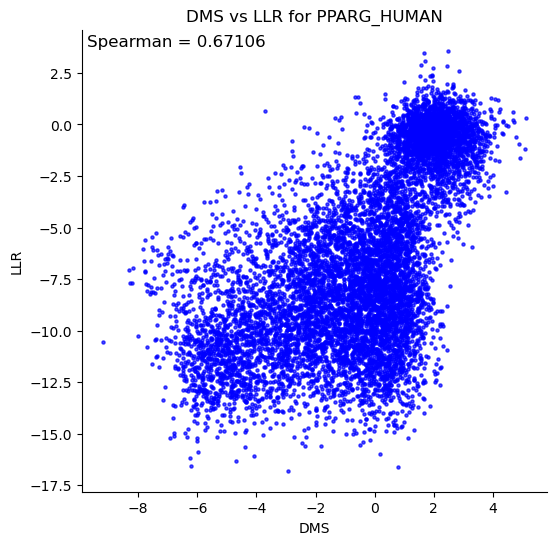

In [18]:
i = 25

x = pg_dict[keys[i]]['DMS']
y = pg_dict[keys[i]]['llr_matrix']

sp_val, p_val = spearman_ignore_nan(x, y)

mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]


# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x_clean, y_clean, color='blue', alpha=0.7, s=5)
plt.xlabel("DMS")
plt.ylabel("LLR")
plt.title(f"DMS vs LLR for {keys[i]}")
plt.grid(False)
ax = plt.gca()
ax.text(
    0.01, 0.99,                
    f"Spearman = {round(sp_val,5)}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    horizontalalignment='left',
)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.show()

/var/folders/30/5r4_75_n4bz34nyphw8tfv3m0000gn/T/ipykernel_4895/2439675481.py:10: RuntimeWarning: invalid value encountered in subtract
  e = np.exp(X_filled - row_max)


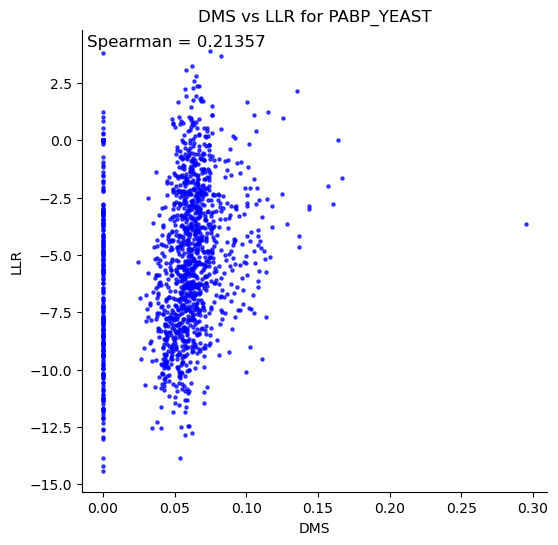

In [21]:
i = 14

x = masked_softmax_rows(pg_dict[keys[i]]['DMS'])
y = pg_dict[keys[i]]['llr_matrix']

sp_val, p_val = spearman_ignore_nan(x, y)

mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]


# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x_clean, y_clean, color='blue', alpha=0.7, s=5)
plt.xlabel("DMS")
plt.ylabel("LLR")
plt.title(f"DMS vs LLR for {keys[i]}")
plt.grid(False)
ax = plt.gca()
ax.text(
    0.01, 0.99,                
    f"Spearman = {round(sp_val,5)}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    horizontalalignment='left',
)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.show()

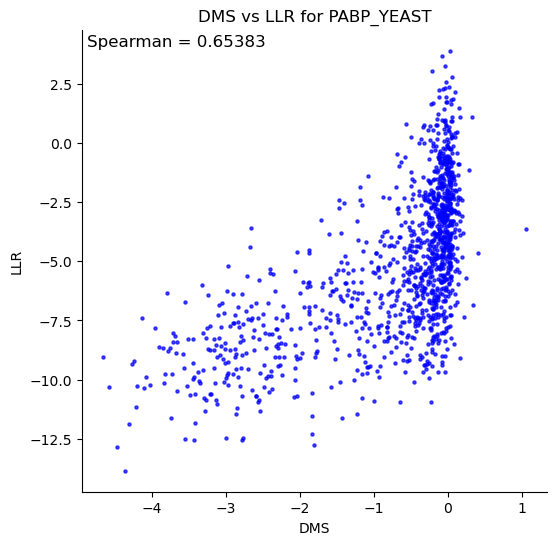

In [23]:
i = 14

x = safe_log(pg_dict[keys[i]]['DMS'])
y = pg_dict[keys[i]]['llr_matrix']

sp_val, p_val = spearman_ignore_nan(x, y)

mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]


# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x_clean, y_clean, color='blue', alpha=0.7, s=5)
plt.xlabel("DMS")
plt.ylabel("LLR")
plt.title(f"DMS vs LLR for {keys[i]}")
plt.grid(False)
ax = plt.gca()
ax.text(
    0.01, 0.99,                
    f"Spearman = {round(sp_val,5)}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    horizontalalignment='left',
)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.show()

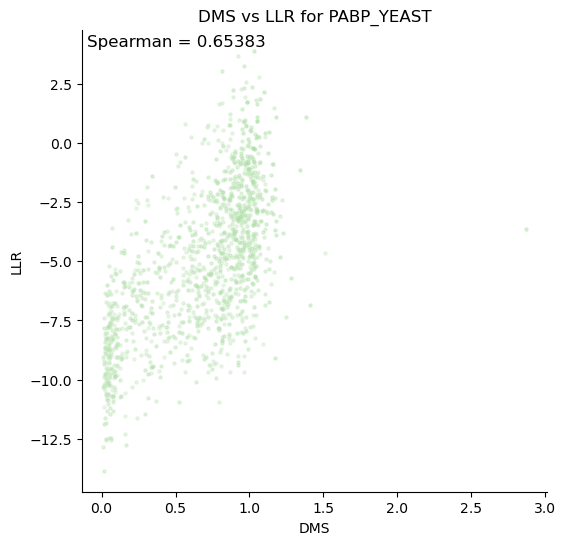

In [20]:
# by position

i = 14

x = pg_dict[keys[i]]['DMS']
y = pg_dict[keys[i]]['llr_matrix']

sp_val, p_val = spearman_ignore_nan(x, y)

x_clean = np.where(np.isnan(x), np.nan, x)
y_clean = np.where(np.isnan(y), np.nan, y)

n_rows = x_clean.shape[0]

# cmap = plt.get_cmap('tab20') 
# colors = cmap(np.linspace(0, 1, n_rows))  

cmap = plt.get_cmap('Greens') 
colors = cmap(np.linspace(0, 1, n_rows))  

plt.figure(figsize=(6, 6))

for j in range(n_rows):
    mask = ~np.isnan(x_clean[j, :]) & ~np.isnan(y_clean[j, :])
    plt.scatter(x_clean[j, mask], y_clean[j, mask], color=colors[j], alpha=0.4, s=5)

plt.xlabel("DMS")
plt.ylabel("LLR")
plt.title(f"DMS vs LLR for {keys[i]}")
plt.grid(False)


ax = plt.gca()
ax.text(
    0.01, 0.99,                
    f"Spearman = {round(sp_val,5)}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    horizontalalignment='left',
)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.show()


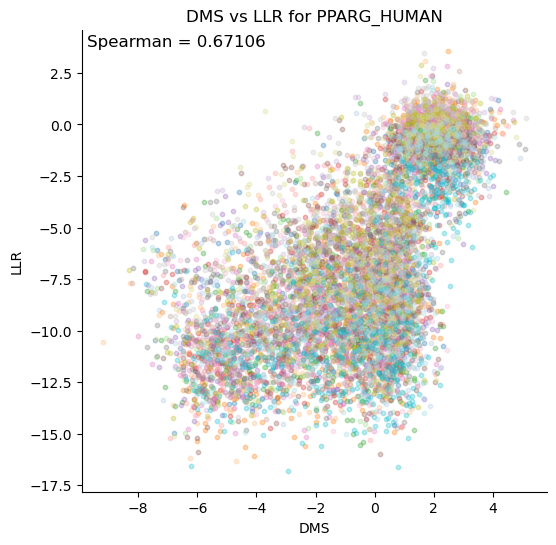

In [44]:
# by amino acid

i = 25

x = pg_dict[keys[i]]['DMS']
y = pg_dict[keys[i]]['llr_matrix']

sp_val, p_val = spearman_ignore_nan(x, y)

x_clean = np.where(np.isnan(x), np.nan, x)
y_clean = np.where(np.isnan(y), np.nan, y)

n_rows = x_clean.shape[0]
n_cols = x_clean.shape[1]

cmap = plt.get_cmap('tab20')  
colors = cmap(np.linspace(0, 1, n_cols))

plt.figure(figsize=(6, 6))

for j in range(n_cols):
    mask = ~np.isnan(x_clean[:, j]) & ~np.isnan(y_clean[:, j])
    # mask = ~np.isnan(x_clean[j, :]) & ~np.isnan(y_clean[j, :])
    # plt.scatter(x_clean[j, mask], y_clean[j, mask], color=colors[j], alpha=0.4)
    plt.scatter(x_clean[mask, j], y_clean[mask, j], color=colors[j], alpha=0.3, s=10)

plt.xlabel("DMS")
plt.ylabel("LLR")
plt.title(f"DMS vs LLR for {keys[i]}")
plt.grid(False)


ax = plt.gca()
ax.text(
    0.01, 0.99,                
    f"Spearman = {round(sp_val,5)}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    horizontalalignment='left',
)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.show()

In [88]:
i=25
DMS = pg_dict[keys[i]]['DMS']
LLR = pg_dict[keys[i]]['llr_matrix']

sp_aa_list = []

for j in range(20):
    x = DMS[:, j]
    y = LLR[:, j]

    corr, p_value = spearman_ignore_nan(x, y)

    sp_aa_list.append(corr)

In [118]:
sp_aa_list = [float(round(x,5)) for x in sp_aa_list]
sp_aa_list=list(zip(list(amino_acids),sp_aa_list))

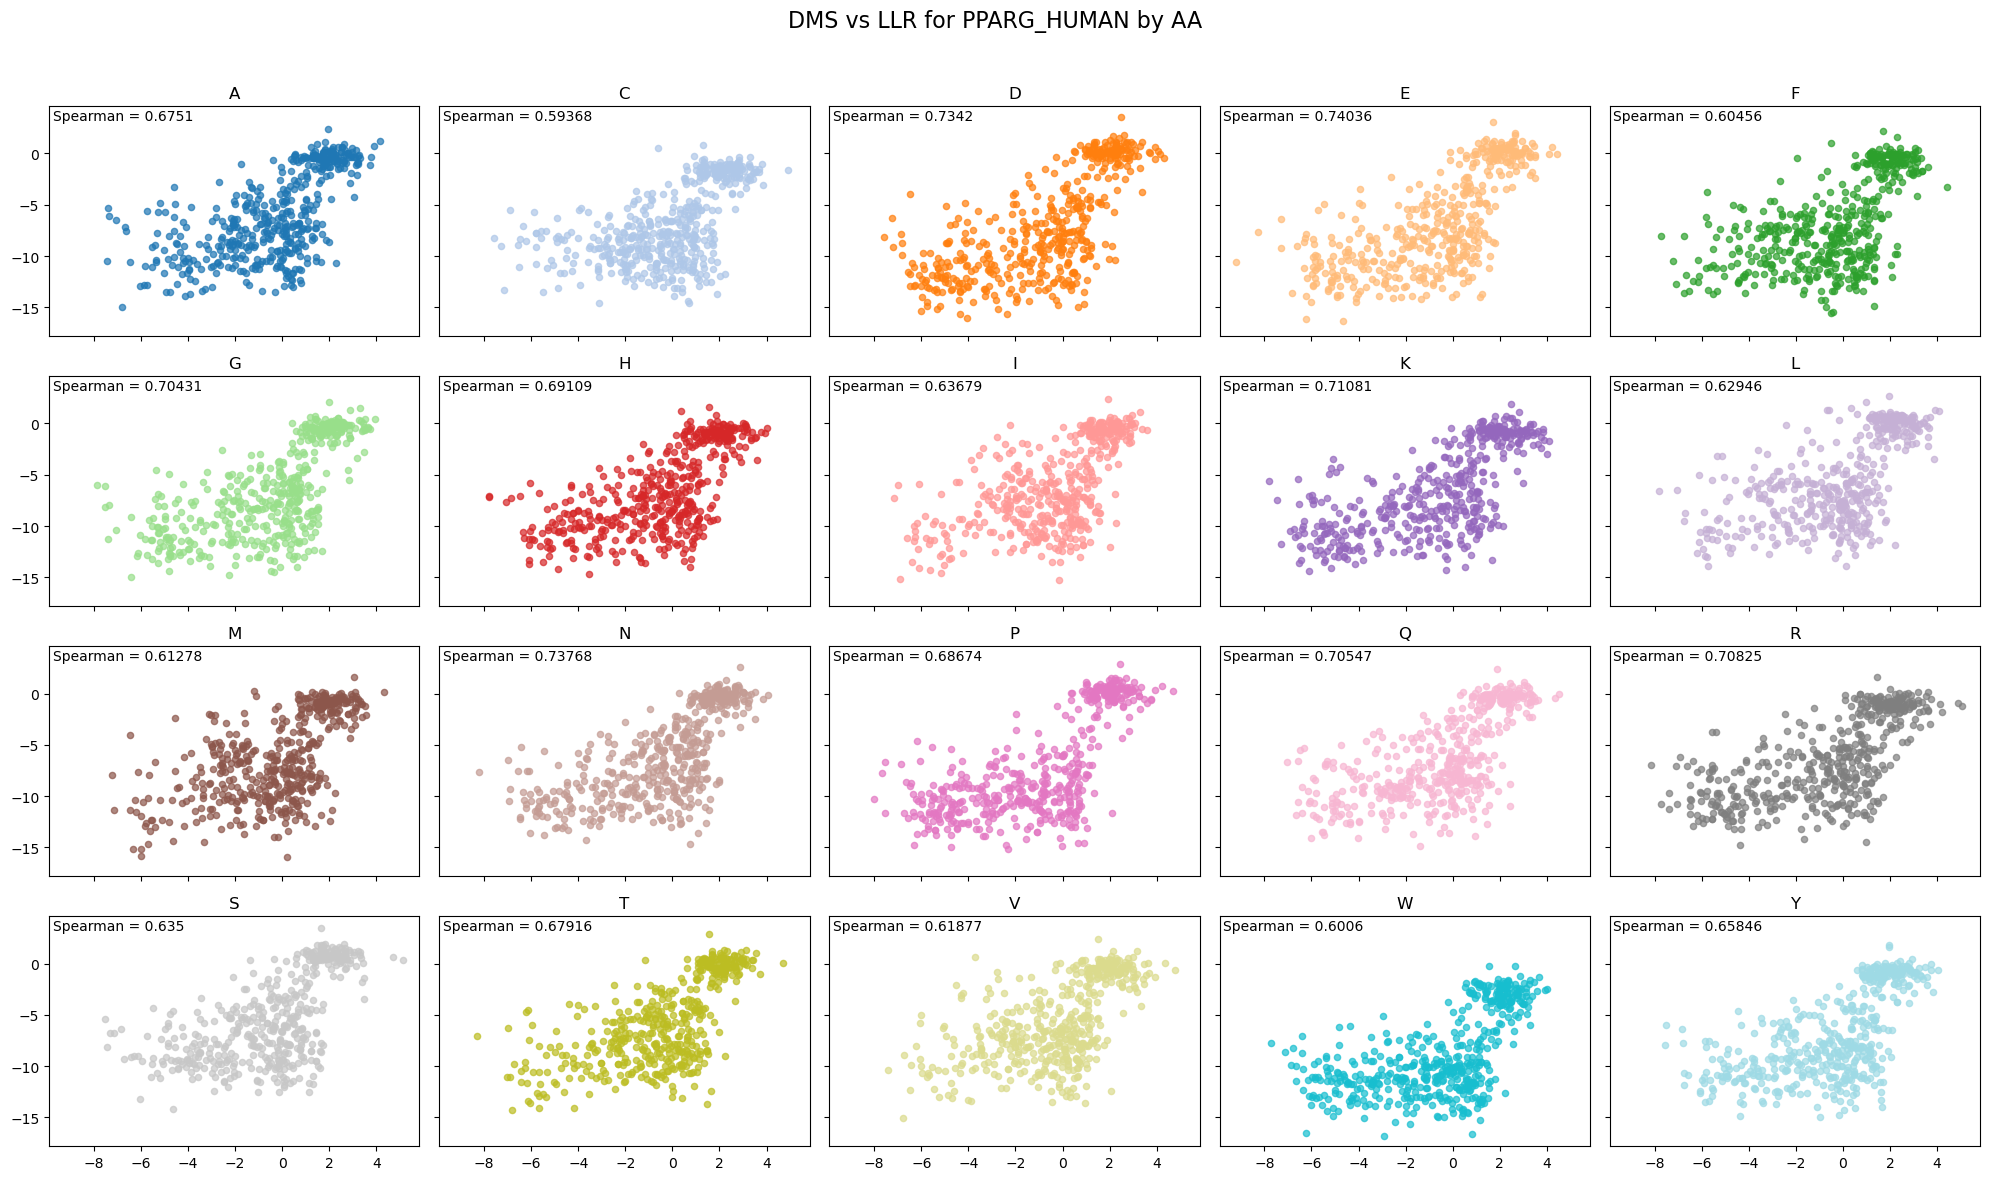

In [ ]:
i = 25
x = pg_dict[keys[i]]['DMS']
y = pg_dict[keys[i]]['llr_matrix']

sp_val, p_val = spearman_ignore_nan(x, y)

x_clean = np.where(np.isnan(x), np.nan, x)
y_clean = np.where(np.isnan(y), np.nan, y)

n_rows, n_cols = x_clean.shape

# Colormap for consistent coloring
cmap = plt.get_cmap('tab20')  
colors = cmap(np.linspace(0, 1, n_cols))

# Determine grid size for panels
n_facets_row = 4
n_facets_col = 5

fig, axes = plt.subplots(n_facets_row, n_facets_col, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()  # flatten for easy indexing

for j in range(n_cols):
    ax = axes[j]
    
    ax.scatter(x_clean[:, j], y_clean[:, j], color=colors[j], alpha=0.7, s=20)
    
    ax.set_title(f'{sp_aa_list[j][0]}')
    ax.grid(False)
   
    ax.text(
        0.01, 0.99,
        f"Spearman = {sp_aa_list[j][1]}",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='left',
    )


fig.suptitle(f"DMS vs LLR for {keys[i]} by AA", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [85]:
len(DMS)

505

In [87]:
# spearman per position
i=25
DMS = pg_dict[keys[i]]['DMS']
LLR = pg_dict[keys[i]]['llr_matrix']

sp_pos_list = []

for j in range(len(DMS)):
    x = DMS[j]
    y = LLR[j]

    corr, p_value = spearman_ignore_nan(x, y)

    sp_pos_list.append(corr)

In [89]:
sp_pos_list = [float(round(x,5)) for x in sp_pos_list]

In [90]:
print(sp_pos_list)

[nan, -0.35614, -0.04561, -0.0614, 0.10175, -0.45965, -0.0807, -0.12281, 0.35965, -0.0386, 0.49123, 0.27895, 0.26842, 0.23333, -0.28596, -0.48246, 0.3386, -0.13509, -0.1386, -0.27895, 0.4502, 0.34386, -0.00175, -0.26491, -0.21579, 0.02456, 0.56491, -0.27368, 0.38947, 0.20702, -0.00263, -0.06491, 0.12807, -0.64211, 0.02982, -0.03333, 0.44561, -0.33158, 0.29311, -0.1, -0.29649, -0.41579, 0.23333, 0.05789, 0.28596, 0.17368, -0.27719, -0.30702, -0.05789, 0.40175, -0.48246, -0.1, -0.26678, -0.26415, -0.15614, -0.13158, 0.32632, 0.14912, 0.10877, -0.28772, -0.27018, -0.00702, -0.14561, -0.02632, 0.24386, 0.06842, -0.09825, 0.12456, 0.31404, -0.13509, -0.12982, -0.24737, -0.01579, 0.00526, 0.06491, 0.16316, 0.12456, 0.21404, -0.26667, -0.03158, -0.16842, 0.25789, -0.47895, -0.0614, -0.17719, -0.10877, 0.13509, 0.36491, 0.15614, -0.11228, -0.20877, -0.1386, -0.05088, -0.04386, 0.24561, -0.16667, 0.00702, 0.2193, 0.37544, -0.07018, -0.1386, -0.46491, -0.15439, -0.1193, -0.1517, -0.07895, 0.2280

In [91]:
len(sp_pos_list)

505

In [108]:
en_sp_pos_list = list(enumerate(sp_pos_list))
en_sp_pos_list = [t for t in en_sp_pos_list if not np.isnan(t[1])]
print(en_sp_pos_list)

[(1, -0.35614), (2, -0.04561), (3, -0.0614), (4, 0.10175), (5, -0.45965), (6, -0.0807), (7, -0.12281), (8, 0.35965), (9, -0.0386), (10, 0.49123), (11, 0.27895), (12, 0.26842), (13, 0.23333), (14, -0.28596), (15, -0.48246), (16, 0.3386), (17, -0.13509), (18, -0.1386), (19, -0.27895), (20, 0.4502), (21, 0.34386), (22, -0.00175), (23, -0.26491), (24, -0.21579), (25, 0.02456), (26, 0.56491), (27, -0.27368), (28, 0.38947), (29, 0.20702), (30, -0.00263), (31, -0.06491), (32, 0.12807), (33, -0.64211), (34, 0.02982), (35, -0.03333), (36, 0.44561), (37, -0.33158), (38, 0.29311), (39, -0.1), (40, -0.29649), (41, -0.41579), (42, 0.23333), (43, 0.05789), (44, 0.28596), (45, 0.17368), (46, -0.27719), (47, -0.30702), (48, -0.05789), (49, 0.40175), (50, -0.48246), (51, -0.1), (52, -0.26678), (53, -0.26415), (54, -0.15614), (55, -0.13158), (56, 0.32632), (57, 0.14912), (58, 0.10877), (59, -0.28772), (60, -0.27018), (61, -0.00702), (62, -0.14561), (63, -0.02632), (64, 0.24386), (65, 0.06842), (66, -0.0

In [110]:
top20pos = sorted(en_sp_pos_list, key=lambda x: x[1], reverse=True)
bot20pos = sorted(en_sp_pos_list, key=lambda x: x[1])
print(top20pos)
print(bot20pos)

[(349, 0.89649), (401, 0.87193), (324, 0.79123), (330, 0.7907), (366, 0.78947), (207, 0.78421), (320, 0.77368), (412, 0.77193), (374, 0.75263), (309, 0.73509), (411, 0.73509), (397, 0.73158), (323, 0.72281), (208, 0.7193), (346, 0.70877), (163, 0.70702), (414, 0.70702), (444, 0.70526), (383, 0.6807), (463, 0.6807), (357, 0.67895), (362, 0.67895), (423, 0.67368), (448, 0.67368), (380, 0.67222), (402, 0.67193), (467, 0.66842), (355, 0.66667), (249, 0.66316), (181, 0.6614), (327, 0.65789), (211, 0.65439), (406, 0.65439), (387, 0.64912), (368, 0.64737), (417, 0.6386), (347, 0.63684), (472, 0.63361), (328, 0.63333), (416, 0.63333), (336, 0.63158), (441, 0.63158), (287, 0.62982), (418, 0.62807), (338, 0.62105), (379, 0.62105), (175, 0.61228), (321, 0.60702), (276, 0.59649), (375, 0.59474), (390, 0.59298), (245, 0.59123), (158, 0.58947), (361, 0.58947), (501, 0.58246), (342, 0.5807), (427, 0.57719), (502, 0.57719), (391, 0.57018), (495, 0.56667), (26, 0.56491), (209, 0.56491), (469, 0.56316),

In [113]:
print(DMS[349])
print(LLR[349])

[-2.834 -2.009 -5.922 -3.395 -3.3   -2.775 -5.886 -1.761 -4.752 -2.183
 -2.281 -4.277 -6.05  -5.1   -6.473 -2.587 -2.251    nan -5.97  -4.55 ]
[ -6.1884613  -9.091515  -10.836281  -10.498016  -10.805054   -8.833206
 -11.345474   -5.786186  -11.349075   -8.379089   -8.40863   -11.114738
 -11.7825165 -11.427887  -11.771515   -9.751091   -8.470184    0.
 -12.999924  -10.167389 ]


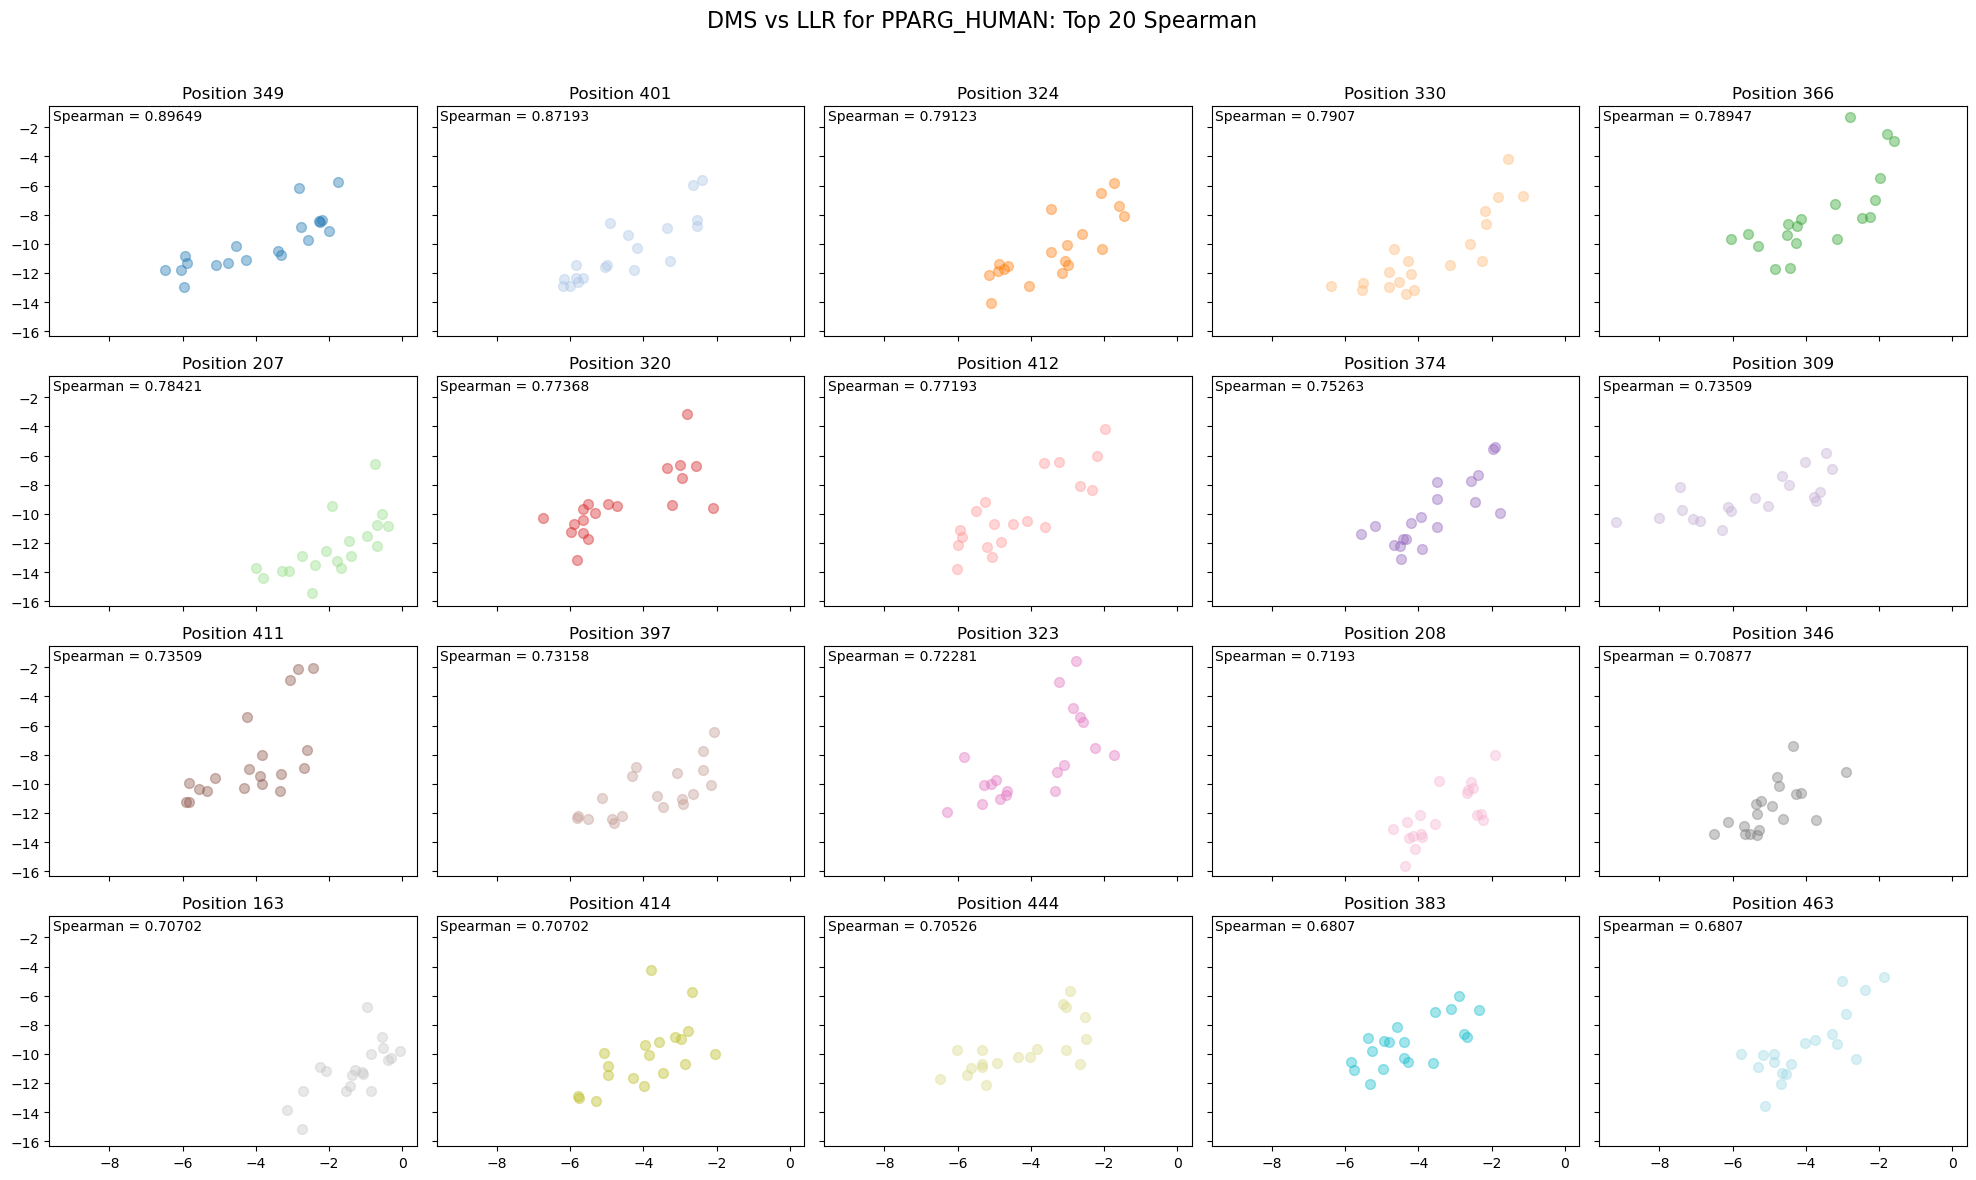

In [121]:
i = 25
x = pg_dict[keys[i]]['DMS']
y = pg_dict[keys[i]]['llr_matrix']

# sp_val, p_val = spearman_ignore_nan(x, y)

x_clean = np.where(np.isnan(x), np.nan, x)
y_clean = np.where(np.isnan(y), np.nan, y)

n_rows, n_cols = x_clean.shape

# Colormap for consistent coloring
cmap = plt.get_cmap('tab20')  
colors = cmap(np.linspace(0, 1, n_cols))

# Determine grid size for panels
n_facets_row = 4
n_facets_col = 5

fig, axes = plt.subplots(n_facets_row, n_facets_col, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()  

for j in range(20):
    ax = axes[j]
    # mask = ~np.isnan(x_clean[j, :]) & ~np.isnan(y_clean[j, :])
    ax.scatter(x_clean[top20pos[j][0]], y_clean[top20pos[j][0]], color=colors[j], alpha=0.4, s=50)
    
    ax.set_title(f'Position {top20pos[j][0]}')
    ax.grid(False)
    
    ax.text(
        0.01, 0.99,
        f"Spearman = {top20pos[j][1]}",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='left',
    )


fig.suptitle(f"DMS vs LLR for {keys[i]}: Top 20 Spearman", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

    

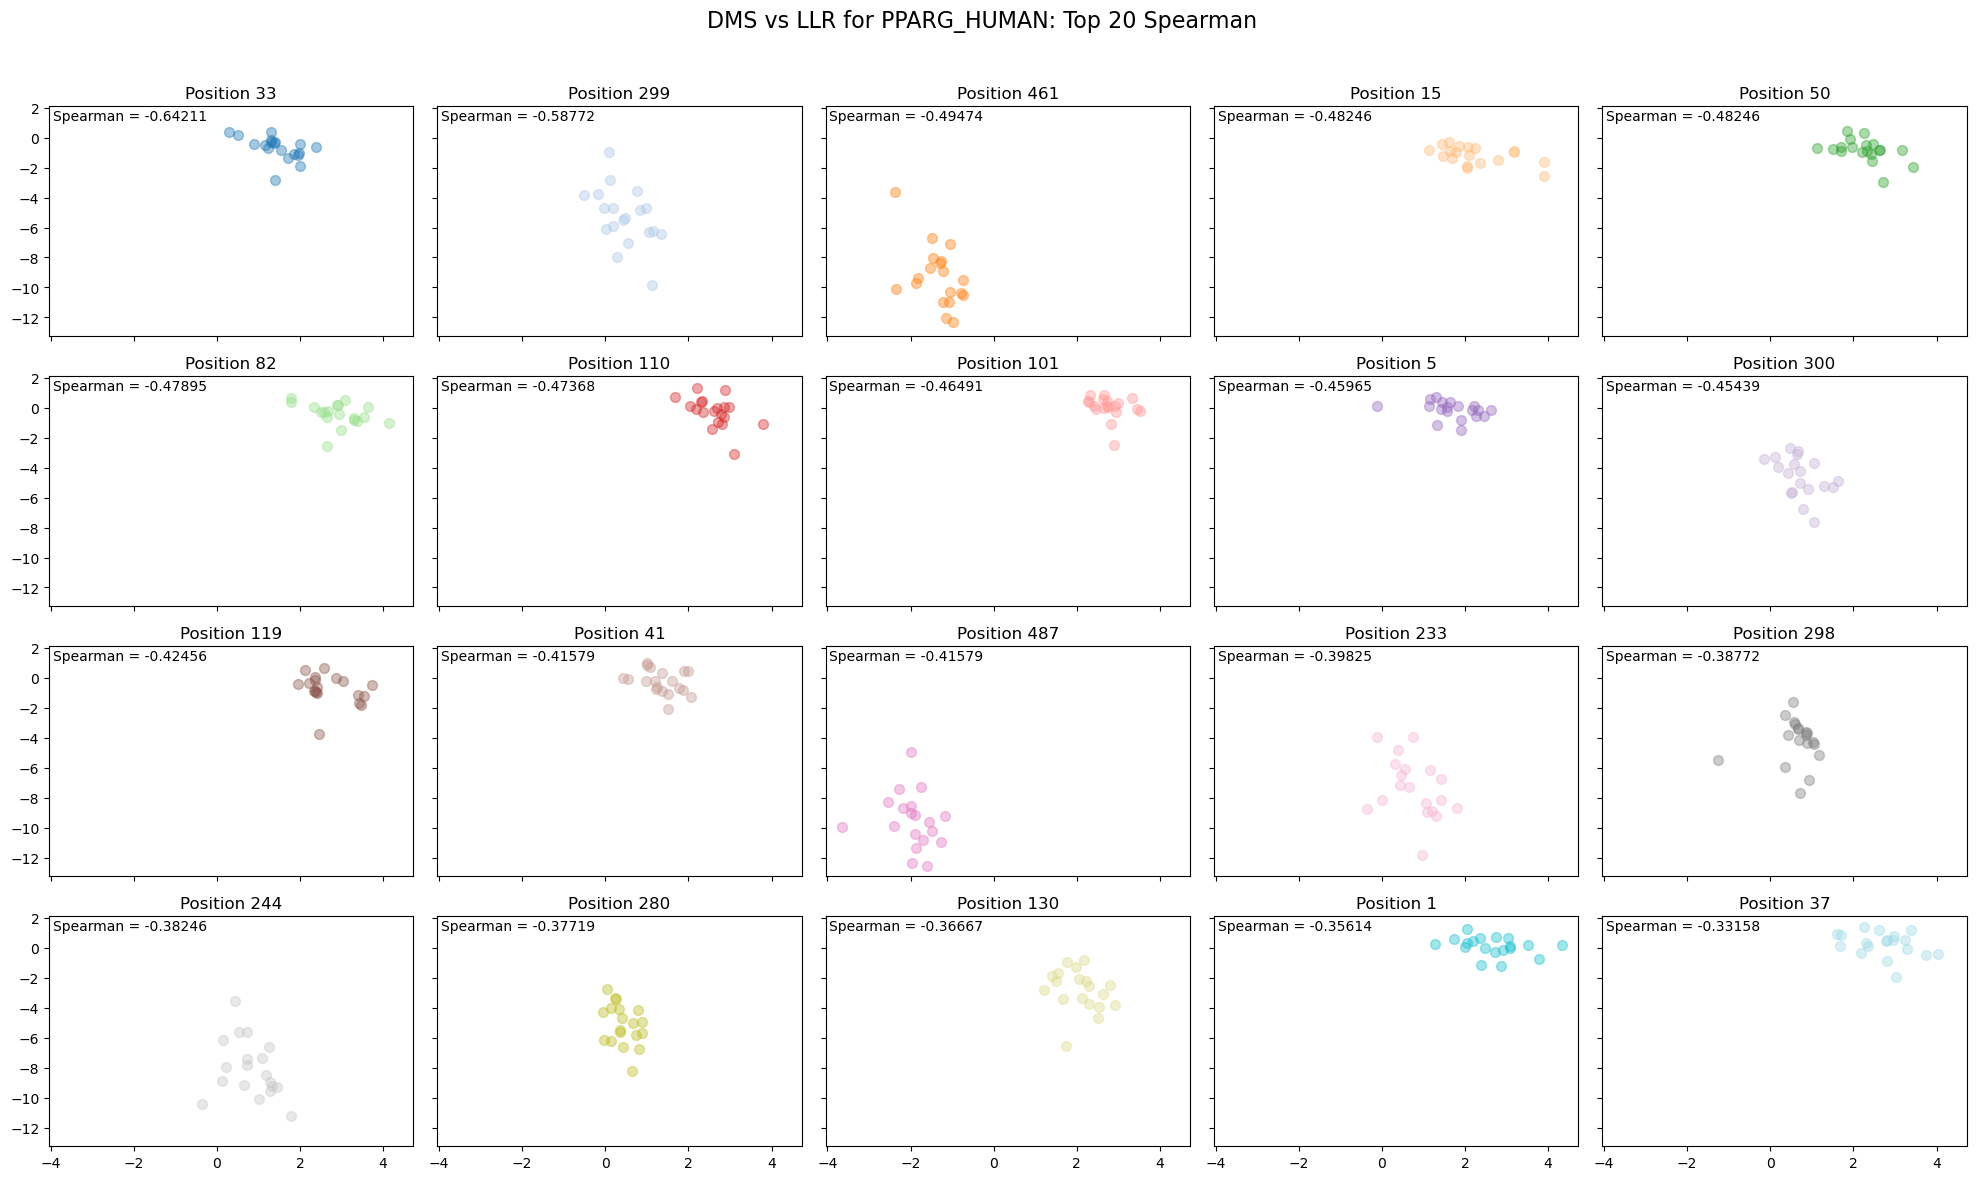

In [122]:
i = 25
x = pg_dict[keys[i]]['DMS']
y = pg_dict[keys[i]]['llr_matrix']

# sp_val, p_val = spearman_ignore_nan(x, y)

x_clean = np.where(np.isnan(x), np.nan, x)
y_clean = np.where(np.isnan(y), np.nan, y)

n_rows, n_cols = x_clean.shape

# Colormap for consistent coloring
cmap = plt.get_cmap('tab20')  
colors = cmap(np.linspace(0, 1, n_cols))

# Determine grid size for panels
n_facets_row = 4
n_facets_col = 5

fig, axes = plt.subplots(n_facets_row, n_facets_col, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()  

for j in range(20):
    ax = axes[j]
    # mask = ~np.isnan(x_clean[j, :]) & ~np.isnan(y_clean[j, :])
    ax.scatter(x_clean[bot20pos[j][0]], y_clean[bot20pos[j][0]], color=colors[j], alpha=0.4, s=50)
    
    ax.set_title(f'Position {bot20pos[j][0]}')
    ax.grid(False)
    
    ax.text(
        0.01, 0.99,
        f"Spearman = {bot20pos[j][1]}",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='left',
    )


fig.suptitle(f"DMS vs LLR for {keys[i]}: Top 20 Spearman", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

    